# AML — XGBoost on GFP + RWPE + Baseline Features

This notebook trains an XGBoost model on the combined feature set:
- **16 baseline edge features** (FX-corrected Amount_Log, OHE payment format, timing, etc.)
- **61 GFP structural features** (scatter-gather, temporal-cycle, lc-cycle histograms + vertex stats)
- **RWPE node features** (8-dim Random Walk Positional Encoding per endpoint, injected as edge features)

Uses the **same 60/20/20 temporal split** as the GNN notebooks.

## Feature inventory

| Group | Cols | Names |
|---|---|---|
| Baseline edge features | 16 | `Amount_Log`, `Currency_Mismatch`, `Hour_Sin/Cos`, etc. |
| GFP pattern histograms | 9 | `scatter-gather_bins_*`, `temp-cycle_bins_*`, `lc-cycle_bins_*` |
| GFP vertex stats | 52 | `source_fan_out`, `dest_avg_amt_in`, etc. |
| RWPE src node (k=1..8) | 8 | `src_rwpe_1` .. `src_rwpe_8` |
| RWPE dst node (k=1..8) | 8 | `dst_rwpe_1` .. `dst_rwpe_8` |
| Src original node feats | 5 | `src_Bank_ID_Norm`, `src_EntType_*` |
| Dst original node feats | 5 | `dst_Bank_ID_Norm`, `dst_EntType_*` |
| **Total** | **103** | |

## RWPE injection strategy

RWPE is computed **per snapshot** using only that snapshot's own edges — no leakage.
For XGBoost, RWPE is lifted from node-space to edge-space by concatenating
the RWPE vectors of both endpoints to each edge's feature vector:

```
edge_feat = [edge_attr(77) | x_src(13) | x_dst(13)]  →  dim = 103
            where x = [Bank_ID_Norm, EntType×4 (5) | rwpe_1..8 (8)]
```

---
## 0. Install & imports

In [1]:
import subprocess, sys

def pip_install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

try:
    import torch_geometric
    print(f'torch_geometric {torch_geometric.__version__} already installed')
except ImportError:
    print('Installing torch-geometric...')
    pip_install('torch-geometric')

try:
    import xgboost
    print(f'xgboost {xgboost.__version__} already installed')
except ImportError:
    print('Installing xgboost...')
    pip_install('xgboost')

c:\Users\User\.conda\envs\signal_processing\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch_geometric 2.7.0 already installed
xgboost 3.2.0 already installed


In [2]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from matplotlib.patches import Patch

import torch
from torch_geometric.transforms import AddRandomWalkPE

import xgboost as xgb

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    confusion_matrix,
)

warnings.filterwarnings('ignore')
print('All imports OK')
print(f'XGBoost version : {xgb.__version__}')
print(f'PyTorch version : {torch.__version__}')

All imports OK
XGBoost version : 3.2.0
PyTorch version : 2.9.1+cpu


---
## 1. Configuration

In [33]:
# ── Paths ─────────────────────────────────────────────────────────────────────
# DATA_DIR must contain:  train_graph_gfp.pt, val_graph_gfp.pt, test_graph_gfp.pt
#                         feature_meta_gfp.json

DATA_DIR = 'Data'   # <- uncomment for local run

SAVE_DIR = 'Models/XGBoost_GFP_RWPE/Predictions'
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs('Models/XGBoost_GFP_RWPE', exist_ok=True)

# ── RWPE config ───────────────────────────────────────────────────────────────
# walk_length=8 covers all 8 AML laundering pattern families:
#   k=2 bilateral  k=3 3-node cycle  k=4 scatter-gather
#   k=5 stack L1   k=6 bipartite inner  k=7-8 full bipartite/stack
RWPE_WALK_LENGTH = 8

# ── XGBoost config ────────────────────────────────────────────────────────────
SEED                 = 42
NUM_BOOST_ROUND      = 1000
EARLY_STOPPING_ROUND = 50
VERBOSE_EVAL         = 50

print('Configuration set.')
print(f'  DATA_DIR         : {DATA_DIR}')
print(f'  SAVE_DIR         : {SAVE_DIR}')
print(f'  RWPE_WALK_LENGTH : {RWPE_WALK_LENGTH}')
print(f'  NUM_BOOST_ROUND  : {NUM_BOOST_ROUND}')

Configuration set.
  DATA_DIR         : Data
  SAVE_DIR         : Models/XGBoost_GFP_RWPE/Predictions
  RWPE_WALK_LENGTH : 8
  NUM_BOOST_ROUND  : 1000


---
## 2. Load feature metadata — real column names

We load the exact column names saved by `Data_preparation_gfp.ipynb` so every
feature in the XGBoost model has a meaningful name (e.g. `scatter-gather_bins_2-3`,
`source_fan_out`) instead of a generic index like `edge_42`.

In [5]:
# ── Load feature metadata from Data_preparation_gfp.ipynb output ─────────────
meta_path = os.path.join(DATA_DIR, 'feature_meta_gfp.json')
with open(meta_path) as f:
    meta = json.load(f)

BASE_EDGE_COLS = meta['BASE_EDGE_COLS']   # 16 baseline edge feature names
GFP_FEAT_COLS  = meta['GFP_FEAT_COLS']    # 61 GFP structural feature names
EDGE_FEAT_COLS = meta['EDGE_FEAT_COLS']   # 77 = BASE_EDGE_COLS + GFP_FEAT_COLS
NODE_FEAT_COLS = meta['NODE_FEAT_COLS']   # 5  original node feature names

print(f'Feature metadata loaded from {meta_path}')
print(f'  BASE_EDGE_COLS : {len(BASE_EDGE_COLS)}  e.g. {BASE_EDGE_COLS[:3]}')
print(f'  GFP_FEAT_COLS  : {len(GFP_FEAT_COLS)}  e.g. {GFP_FEAT_COLS[:3]}')
print(f'  EDGE_FEAT_COLS : {len(EDGE_FEAT_COLS)}  (= baseline + GFP)')
print(f'  NODE_FEAT_COLS : {len(NODE_FEAT_COLS)}  {NODE_FEAT_COLS}')

# ── RWPE adds 8 new dims per node — build their names ────────────────────────
RWPE_COLS = [f'rwpe_{k}' for k in range(1, RWPE_WALK_LENGTH + 1)]
# Full per-node feature names after RWPE injection: [5 original | 8 RWPE]
NODE_FEAT_COLS_WITH_RWPE = NODE_FEAT_COLS + RWPE_COLS   # 13 names

# ── Final 103-dim edge feature names for XGBoost ─────────────────────────────
# Prefix src/dst so names don't collide (e.g. src_Bank_ID_Norm vs dst_Bank_ID_Norm)
SRC_FEAT_NAMES = [f'src_{c}' for c in NODE_FEAT_COLS_WITH_RWPE]   # 13
DST_FEAT_NAMES = [f'dst_{c}' for c in NODE_FEAT_COLS_WITH_RWPE]   # 13
FEAT_NAMES     = EDGE_FEAT_COLS + SRC_FEAT_NAMES + DST_FEAT_NAMES  # 103

print(f'\nFinal XGBoost feature names: {len(FEAT_NAMES)}')
print(f'  Edge (77)   : {EDGE_FEAT_COLS[:2]} ... {EDGE_FEAT_COLS[-2:]}')
print(f'  Src node(13): {SRC_FEAT_NAMES[:2]} ... {SRC_FEAT_NAMES[-2:]}')
print(f'  Dst node(13): {DST_FEAT_NAMES[:2]} ... {DST_FEAT_NAMES[-2:]}')
assert len(FEAT_NAMES) == len(EDGE_FEAT_COLS) + 2 * len(NODE_FEAT_COLS_WITH_RWPE)
print('Feature name count assertion passed ✓')

Feature metadata loaded from Data\feature_meta_gfp.json
  BASE_EDGE_COLS : 16  e.g. ['Amount_Log', 'Currency_Mismatch', 'Hour_Sin']
  GFP_FEAT_COLS  : 61  e.g. ['scatter-gather_bins_2-3', 'scatter-gather_bins_3-5', 'scatter-gather_bins_5-inf']
  EDGE_FEAT_COLS : 77  (= baseline + GFP)
  NODE_FEAT_COLS : 5  ['Bank_ID_Norm', 'EntityType_Corporation', 'EntityType_Individual', 'EntityType_Partnership', 'EntityType_Sole']

Final XGBoost feature names: 103
  Edge (77)   : ['Amount_Log', 'Currency_Mismatch'] ... ['dest_skew_amt_in', 'dest_kurtosis_amt_in']
  Src node(13): ['src_Bank_ID_Norm', 'src_EntityType_Corporation'] ... ['src_rwpe_7', 'src_rwpe_8']
  Dst node(13): ['dst_Bank_ID_Norm', 'dst_EntityType_Corporation'] ... ['dst_rwpe_7', 'dst_rwpe_8']
Feature name count assertion passed ✓


---
## 3. Load PyG graph snapshots

In [16]:
print('Loading graph snapshots...')

train_graph = torch.load(os.path.join(DATA_DIR, 'train_graph_gfp.pt'), weights_only=False)
val_graph   = torch.load(os.path.join(DATA_DIR, 'val_graph_gfp.pt'),   weights_only=False)
test_graph  = torch.load(os.path.join(DATA_DIR, 'test_graph_gfp.pt'),  weights_only=False)


def describe_graph(g, name):
    """
    Print a summary of one graph snapshot.

    Shows the number of nodes, total edges, how many edges are
    evaluated in this split, and the laundering rate among them.
    """
    labels = g.y[g.eval_mask]
    n_pos  = (labels == 1).sum().item()
    n_eval = g.eval_mask.sum().item()
    print(f'{name}:')
    print(f'  Nodes          : {g.num_nodes:,}')
    print(f'  Edges (total)  : {g.edge_index.shape[1]:,}')
    print(f'  Eval edges     : {n_eval:,}')
    print(f'  Laundering     : {n_pos:,}  ({100*n_pos/n_eval:.4f}%)')
    print(f'  Node feat dim  : {g.x.shape[1]}')
    print(f'  Edge feat dim  : {g.edge_attr.shape[1]}')
    print()


describe_graph(train_graph, 'train_graph')
describe_graph(val_graph,   'val_graph')
describe_graph(test_graph,  'test_graph')

# Sanity check: no -1 labels in eval sets
for g, name in [(train_graph, 'train'), (val_graph, 'val'), (test_graph, 'test')]:
    labels = g.y[g.eval_mask]
    assert (labels == -1).sum() == 0, f'{name}: -1 labels found in eval set!'
    assert set(labels.unique().tolist()) <= {0, 1}
print('Label sanity check passed -- no -1 values in eval masks.')

# Confirm edge_attr dim matches what feature_meta_gfp.json says
assert train_graph.edge_attr.shape[1] == len(EDGE_FEAT_COLS), (
    f'edge_attr dim {train_graph.edge_attr.shape[1]} != EDGE_FEAT_COLS {len(EDGE_FEAT_COLS)}')
print(f'edge_attr dim check passed ✓  ({len(EDGE_FEAT_COLS)} features)')

Loading graph snapshots...
train_graph:
  Nodes          : 712,684
  Edges (total)  : 4,154,429
  Eval edges     : 4,154,429
  Laundering     : 1,813  (0.0436%)
  Node feat dim  : 5
  Edge feat dim  : 77

val_graph:
  Nodes          : 712,684
  Edges (total)  : 5,539,239
  Eval edges     : 1,384,810
  Laundering     : 827  (0.0597%)
  Node feat dim  : 5
  Edge feat dim  : 77

test_graph:
  Nodes          : 712,684
  Edges (total)  : 6,924,049
  Eval edges     : 1,384,810
  Laundering     : 925  (0.0668%)
  Node feat dim  : 5
  Edge feat dim  : 77

Label sanity check passed -- no -1 values in eval masks.
edge_attr dim check passed ✓  (77 features)


---
## 4. Inject RWPE into each snapshot

RWPE encodes the probability of returning to a node in exactly k steps.
Computed **per snapshot** using only that snapshot's own edges — no leakage.

After RWPE:
- `graph.x` shape: `[N, 5]` → `[N, 13]`  (original 5 node features + 8 RWPE dims)
- `graph.edge_attr` is **unchanged** at this stage (still 77-dim)

In [17]:
def add_rwpe(graph, walk_length=RWPE_WALK_LENGTH):
    """
    Compute RWPE from this snapshot's edge_index and concatenate into graph.x.
    Reads only graph.edge_index (topology) — timestamps and edge_attr untouched.

    What it encodes: RWPE(node_i, k) = probability of returning to node_i
    in exactly k steps under a random walk following edge direction.

    walk_length=8 covers all 8 AML laundering pattern families:
      k=2 bilateral      k=3 3-node cycle     k=4 scatter-gather
      k=5 stack layer 1  k=6 bipartite inner  k=7-8 full bipartite/stack

    Parameters
    ----------
    graph       : PyG Data object
    walk_length : number of RWPE dimensions (default=8)

    Returns
    -------
    graph with graph.x updated from [N, 5] to [N, 5+walk_length]
    """
    transform = AddRandomWalkPE(walk_length=walk_length, attr_name='rwpe')
    graph = transform(graph)                              # graph.rwpe: [N, 8]
    graph.x = torch.cat([graph.x, graph.rwpe], dim=-1)  # [N, 5] -> [N, 13]
    del graph.rwpe
    return graph


print(f'Computing RWPE per snapshot (walk_length={RWPE_WALK_LENGTH})...')
train_graph = add_rwpe(train_graph)
print(f'  train_graph node dim: {train_graph.x.shape[1]}')
val_graph   = add_rwpe(val_graph)
print(f'  val_graph   node dim: {val_graph.x.shape[1]}')
test_graph  = add_rwpe(test_graph)
print(f'  test_graph  node dim: {test_graph.x.shape[1]}')
print('RWPE done.')

# Confirm the resulting node dim matches our name list
assert train_graph.x.shape[1] == len(NODE_FEAT_COLS_WITH_RWPE), (
    f'node dim {train_graph.x.shape[1]} != NODE_FEAT_COLS_WITH_RWPE {len(NODE_FEAT_COLS_WITH_RWPE)}')
print(f'Node feat dim check passed ✓  '
      f'({len(NODE_FEAT_COLS)} original + {RWPE_WALK_LENGTH} RWPE = {len(NODE_FEAT_COLS_WITH_RWPE)})')

for g, name in [(train_graph, 'train'), (val_graph, 'val'), (test_graph, 'test')]:
    labels = g.y[g.eval_mask]
    assert (labels == -1).sum() == 0, f'{name}: -1 labels found in eval set!'
    assert set(labels.unique().tolist()) <= {0, 1}
print('Label sanity check passed -- no -1 values in eval masks.')

Computing RWPE per snapshot (walk_length=8)...
  train_graph node dim: 13
  val_graph   node dim: 13
  test_graph  node dim: 13
RWPE done.
Node feat dim check passed ✓  (5 original + 8 RWPE = 13)
Label sanity check passed -- no -1 values in eval masks.


---
## 5. Assemble tabular feature matrix for XGBoost

XGBoost operates on flat feature vectors per edge.
For each edge `(src → dst)` we build:

```
X_edge = [edge_attr (77) | x[src] (13) | x[dst] (13)]  →  dim = 103
```

Column names come from `FEAT_NAMES` (loaded from `feature_meta_gfp.json` + RWPE suffixes),
so every feature is human-readable in the importance plot.

In [19]:
def extract_tabular_features(graph, split_name):
    """
    Assemble flat feature matrix for XGBoost from a PyG graph snapshot.

    For each edge in the eval_mask:
        X = [edge_attr (77) | x[src] (13) | x[dst] (13)]  →  dim = 103

    node x[i] = [Bank_ID_Norm, EntType_Corporation, EntType_Individual,
                 EntType_Partnership, EntType_Sole  (5 original)
                 rwpe_1 .. rwpe_8                   (8 RWPE)]

    Parameters
    ----------
    graph      : PyG Data object (after RWPE injection, x dim = 13)
    split_name : string label for printing

    Returns
    -------
    X : np.ndarray  shape [n_eval_edges, 103]  — float32
    y : np.ndarray  shape [n_eval_edges]        — int32 (0 or 1)
    """
    eval_mask = graph.eval_mask                           # [E] bool

    # ── Edge features: 77-dim (baseline + GFP) ───────────────────────────────
    edge_attr = graph.edge_attr[eval_mask].numpy()        # [E_eval, 77]
    labels    = graph.y[eval_mask].numpy()                # [E_eval]

    # ── Source and destination node indices for eval edges ───────────────────
    src_idx = graph.edge_index[0][eval_mask].numpy()      # [E_eval]
    dst_idx = graph.edge_index[1][eval_mask].numpy()      # [E_eval]

    # ── Node features: 13-dim (5 original + 8 RWPE) ──────────────────────────
    node_feats = graph.x.numpy()                          # [N, 13]
    src_feats  = node_feats[src_idx]                      # [E_eval, 13]
    dst_feats  = node_feats[dst_idx]                      # [E_eval, 13]

    # ── Concatenate: [edge_attr | src_node | dst_node] ───────────────────────
    X = np.concatenate([edge_attr, src_feats, dst_feats], axis=1)  # [E_eval, 103]
    y = labels.astype(np.int32)

    # Confirm dim matches FEAT_NAMES
    assert X.shape[1] == len(FEAT_NAMES), (
        f'[{split_name}] X dim {X.shape[1]} != FEAT_NAMES {len(FEAT_NAMES)}')

    n_pos  = y.sum()
    n_eval = len(y)
    print(f'{split_name}:  X={X.shape}  |  '
          f'pos={n_pos:,}  neg={n_eval-n_pos:,}  rate={100*n_pos/n_eval:.4f}%')
    return X.astype(np.float32), y


print('Assembling tabular feature matrices...')
X_train, y_train = extract_tabular_features(train_graph, 'Train')
X_val,   y_val   = extract_tabular_features(val_graph,   'Val  ')
X_test,  y_test  = extract_tabular_features(test_graph,  'Test ')

print(f'\nFeature breakdown ({len(FEAT_NAMES)} total):')
print(f'  Edge features (baseline)  : {len(BASE_EDGE_COLS):>3}  '
      f'e.g. {BASE_EDGE_COLS[:2]}')
print(f'  Edge features (GFP)       : {len(GFP_FEAT_COLS):>3}  '
      f'e.g. {GFP_FEAT_COLS[:2]}')
print(f'  Src node feats (original) :   5  {NODE_FEAT_COLS}')
print(f'  Src node feats (RWPE)     :   {RWPE_WALK_LENGTH}  {RWPE_COLS}')
print(f'  Dst node feats (original) :   5  (same, prefixed dst_)')
print(f'  Dst node feats (RWPE)     :   {RWPE_WALK_LENGTH}  (same, prefixed dst_)')

Assembling tabular feature matrices...
Train:  X=(4154429, 103)  |  pos=1,813  neg=4,152,616  rate=0.0436%
Val  :  X=(1384810, 103)  |  pos=827  neg=1,383,983  rate=0.0597%
Test :  X=(1384810, 103)  |  pos=925  neg=1,383,885  rate=0.0668%

Feature breakdown (103 total):
  Edge features (baseline)  :  16  e.g. ['Amount_Log', 'Currency_Mismatch']
  Edge features (GFP)       :  61  e.g. ['scatter-gather_bins_2-3', 'scatter-gather_bins_3-5']
  Src node feats (original) :   5  ['Bank_ID_Norm', 'EntityType_Corporation', 'EntityType_Individual', 'EntityType_Partnership', 'EntityType_Sole']
  Src node feats (RWPE)     :   8  ['rwpe_1', 'rwpe_2', 'rwpe_3', 'rwpe_4', 'rwpe_5', 'rwpe_6', 'rwpe_7', 'rwpe_8']
  Dst node feats (original) :   5  (same, prefixed dst_)
  Dst node feats (RWPE)     :   8  (same, prefixed dst_)


---
## 6. Class imbalance — compute scale_pos_weight

In [35]:
neg_train = (y_train == 0).sum()
pos_train = (y_train == 1).sum()
scale_pos_weight = neg_train / pos_train
scale_pos_weight = 10.0

print(f'Train class counts:')
print(f'  Negative (legit)    : {neg_train:,}')
print(f'  Positive (launder)  : {pos_train:,}')
print(f'  Imbalance ratio     : {scale_pos_weight:.1f}x')
print(f'  scale_pos_weight    : {scale_pos_weight:.2f}')

Train class counts:
  Negative (legit)    : 4,152,616
  Positive (launder)  : 1,813
  Imbalance ratio     : 10.0x
  scale_pos_weight    : 10.00


---
## 7. Build XGBoost DMatrix objects

We pass `feature_names=FEAT_NAMES` so XGBoost stores the real names internally.
This makes `get_score()` and `plot_importance()` use meaningful labels automatically.

In [21]:
# XGBoost feature names must not contain special chars [ ] <
# Replace any such chars produced by GFP column names
safe_feat_names = [n.replace('[', '(').replace(']', ')').replace('<', 'lt') for n in FEAT_NAMES]

print('Building DMatrix objects...')
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=safe_feat_names)
dval   = xgb.DMatrix(X_val,   label=y_val,   feature_names=safe_feat_names)
dtest  = xgb.DMatrix(X_test,  label=y_test,  feature_names=safe_feat_names)
print(f'DMatrix objects ready.  Feature names sample: {safe_feat_names[:3]} ... {safe_feat_names[-3:]}')

Building DMatrix objects...
DMatrix objects ready.  Feature names sample: ['Amount_Log', 'Currency_Mismatch', 'Hour_Sin'] ... ['dst_rwpe_6', 'dst_rwpe_7', 'dst_rwpe_8']


---
## 8. Train XGBoost

In [36]:
params = {
    'objective'        : 'binary:logistic',
    'eval_metric'      : ['auc', 'aucpr', 'logloss'],   # logloss is primary early-stop metric
    'scale_pos_weight' : scale_pos_weight,        # handles severe class imbalance
    'max_depth'        : 6,
    'learning_rate'    : 0.05,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'min_child_weight' : 10,
    'gamma'            : 1.0,
    'tree_method'      : 'hist',   # change to 'gpu_hist' if GPU available
    'seed'             : SEED,
}

print('XGBoost hyperparameters:')
for k, v in params.items():
    print(f'  {k:<22}: {v}')

print(f'\nTraining (max {NUM_BOOST_ROUND} rounds, early stopping={EARLY_STOPPING_ROUND} on val logloss)...')

evals_result = {}
model = xgb.train(
    params,
    dtrain,
    num_boost_round=NUM_BOOST_ROUND,
    evals=[(dtrain, 'train'), (dval, 'val')],
    early_stopping_rounds=EARLY_STOPPING_ROUND,
    evals_result=evals_result,
    verbose_eval=VERBOSE_EVAL,
)

print(f'\nTraining complete.')
print(f'  Best round     : {model.best_iteration}')
print(f'  Best val logloss : {model.best_score:.4f}')

XGBoost hyperparameters:
  objective             : binary:logistic
  eval_metric           : ['auc', 'aucpr', 'logloss']
  scale_pos_weight      : 10.0
  max_depth             : 6
  learning_rate         : 0.05
  subsample             : 0.8
  colsample_bytree      : 0.8
  min_child_weight      : 10
  gamma                 : 1.0
  tree_method           : hist
  seed                  : 42

Training (max 1000 rounds, early stopping=50 on val logloss)...
[0]	train-auc:0.95965	train-aucpr:0.09564	train-logloss:0.12336	val-auc:0.94500	val-aucpr:0.09872	val-logloss:0.12369
[50]	train-auc:0.98339	train-aucpr:0.18643	train-logloss:0.01369	val-auc:0.97088	val-aucpr:0.12916	val-logloss:0.01444
[100]	train-auc:0.98965	train-aucpr:0.21964	train-logloss:0.00500	val-auc:0.97263	val-aucpr:0.15053	val-logloss:0.00589
[150]	train-auc:0.99227	train-aucpr:0.24853	train-logloss:0.00410	val-auc:0.97360	val-aucpr:0.15320	val-logloss:0.00501
[200]	train-auc:0.99473	train-aucpr:0.30827	train-logloss:0.00376	va

---
## 9. Training curves

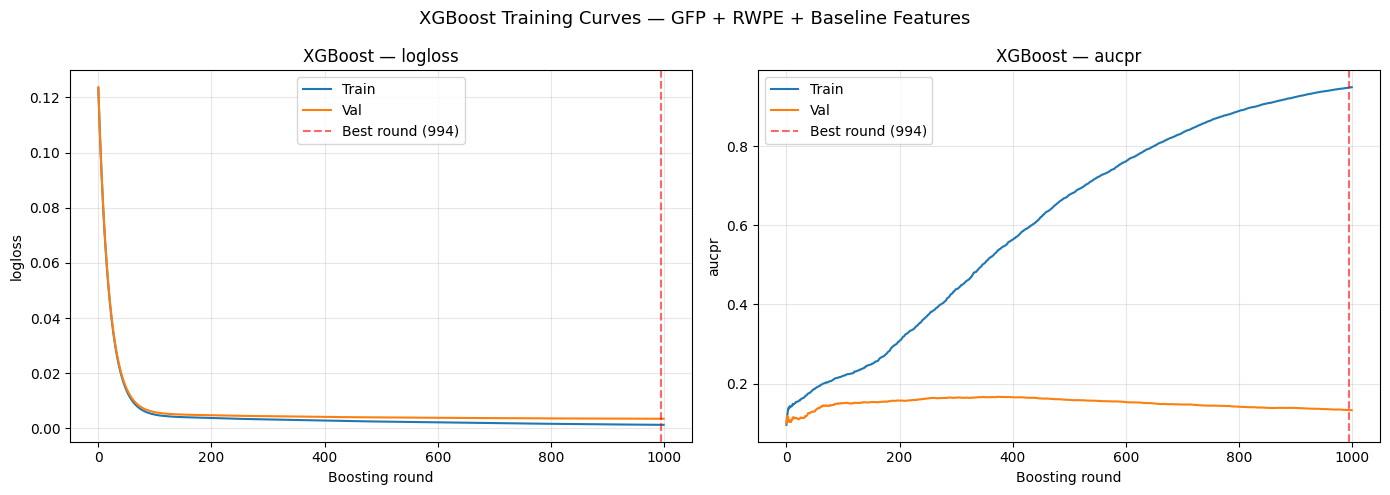

Training curves saved.


In [37]:
best_round = model.best_iteration

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axes, ['logloss', 'aucpr']):
    ax.plot(evals_result['train'][metric], label='Train', linewidth=1.5)
    ax.plot(evals_result['val'][metric],   label='Val',   linewidth=1.5)
    ax.axvline(best_round, color='red', linestyle='--', alpha=0.6,
               label=f'Best round ({best_round})')
    ax.set_xlabel('Boosting round')
    ax.set_ylabel(metric)
    ax.set_title(f'XGBoost — {metric}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('XGBoost Training Curves — GFP + RWPE + Baseline Features', fontsize=13)
plt.tight_layout()
plt.savefig('Models/XGBoost_GFP_RWPE/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Training curves saved.')

---
## 10. Evaluation

Same metrics as the GNN notebooks: ROC-AUC, PR-AUC, F1@0.5, best F1, best MCC.

In [38]:
def evaluate(model, dmat, y_true, split_name, threshold_grid=None):
    """
    Evaluate XGBoost predictions on a given split.

    Parameters
    ----------
    model         : trained xgb.Booster
    dmat          : xgb.DMatrix
    y_true        : np.ndarray of ground-truth labels
    split_name    : string label for printing
    threshold_grid: iterable of thresholds to sweep (default 0.01..0.99 step 0.01)

    Returns
    -------
    probs   : np.ndarray of predicted probabilities
    metrics : dict of metric name → value
    """
    if threshold_grid is None:
        threshold_grid = np.arange(0.01, 0.99, 0.01)

    # probs = model.predict(dmat, iteration_range=(0, model.best_iteration + 1))
    probs = model.predict(dmat, iteration_range=(0, 75))

    roc_auc = roc_auc_score(y_true, probs)
    pr_auc  = average_precision_score(y_true, probs)

    preds_05 = (probs >= 0.5).astype(int)
    f1_05    = f1_score(y_true, preds_05, zero_division=0)

    best_f1 = best_mcc = 0.0
    best_thr_f1 = best_thr_mcc = 0.5
    best_prec = best_rec = 0.0

    for thr in threshold_grid:
        preds = (probs >= thr).astype(int)
        f1  = f1_score(y_true, preds, zero_division=0)
        mcc = matthews_corrcoef(y_true, preds)
        if f1 > best_f1:
            best_f1     = f1
            best_thr_f1 = thr
            tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
            best_prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            best_rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        if mcc > best_mcc:
            best_mcc     = mcc
            best_thr_mcc = thr

    metrics = dict(
        roc_auc      = roc_auc,
        pr_auc       = pr_auc,
        f1_05        = f1_05,
        best_f1      = best_f1,
        best_thr_f1  = best_thr_f1,
        precision    = best_prec,
        recall       = best_rec,
        best_mcc     = best_mcc,
        best_thr_mcc = best_thr_mcc,
    )

    print(f'\n── {split_name} ─────────────────────────────────')
    print(f'  ROC-AUC         : {roc_auc:.4f}')
    print(f'  PR-AUC          : {pr_auc:.4f}')
    print(f'  F1 @ thr=0.5    : {f1_05:.4f}')
    print(f'  Best F1         : {best_f1:.4f}  (thr={best_thr_f1:.2f})')
    print(f'    Precision      : {best_prec:.4f}')
    print(f'    Recall         : {best_rec:.4f}')
    print(f'  Best MCC        : {best_mcc:.4f}  (thr={best_thr_mcc:.2f})')
    return probs, metrics


train_probs, train_metrics = evaluate(model, dtrain, y_train, 'Train')
val_probs,   val_metrics   = evaluate(model, dval,   y_val,   'Validation')
test_probs,  test_metrics  = evaluate(model, dtest,  y_test,  'Test')


── Train ─────────────────────────────────
  ROC-AUC         : 0.9867
  PR-AUC          : 0.2046
  F1 @ thr=0.5    : 0.2197
  Best F1         : 0.2291  (thr=0.45)
    Precision      : 0.2916
    Recall         : 0.1886
  Best MCC        : 0.2857  (thr=0.59)

── Validation ─────────────────────────────────
  ROC-AUC         : 0.9717
  PR-AUC          : 0.1443
  F1 @ thr=0.5    : 0.1384
  Best F1         : 0.1809  (thr=0.33)
    Precision      : 0.1793
    Recall         : 0.1826
  Best MCC        : 0.2216  (thr=0.57)

── Test ─────────────────────────────────
  ROC-AUC         : 0.9755
  PR-AUC          : 0.1190
  F1 @ thr=0.5    : 0.0767
  Best F1         : 0.1791  (thr=0.23)
    Precision      : 0.1373
    Recall         : 0.2573
  Best MCC        : 0.1997  (thr=0.13)


---
## 11. Precision-Recall curves

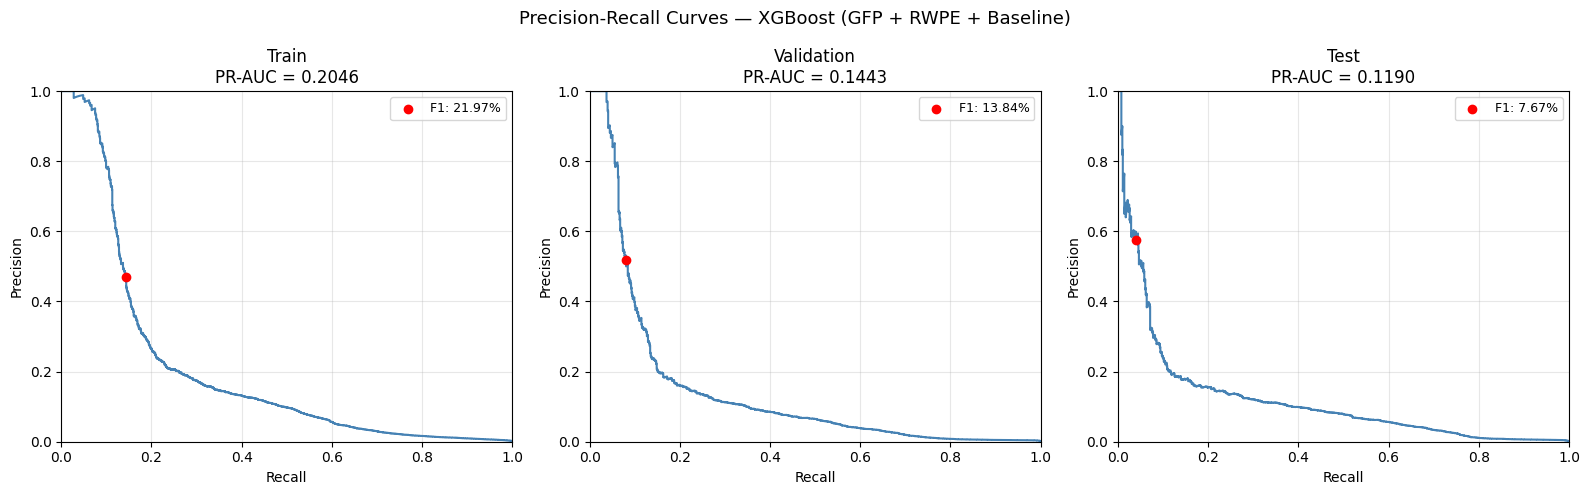

PR curves saved.


In [39]:
def plot_pr_curve(ax, probs, y_true, metrics, title):
    prec, rec, _ = precision_recall_curve(y_true, probs)

    ax.plot(rec, prec, color='steelblue', linewidth=1.5)

    # Red dot at threshold=0.5 (paper convention)
    preds_05       = (probs >= 0.5).astype(int)
    cm             = confusion_matrix(y_true, preds_05)
    tn, fp, fn, tp = cm.ravel() if preds_05.sum() > 0 else (cm[0,0], 0, cm[1,0], 0)
    p05 = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    r05 = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    ax.scatter([r05], [p05], color='red', zorder=5,
               label=f'F1: {metrics["f1_05"]*100:.2f}%')

    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'{title}\nPR-AUC = {metrics["pr_auc"]:.4f}')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)


fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_pr_curve(axes[0], train_probs, y_train, train_metrics, 'Train')
plot_pr_curve(axes[1], val_probs,   y_val,   val_metrics,   'Validation')
plot_pr_curve(axes[2], test_probs,  y_test,  test_metrics,  'Test')

plt.suptitle('Precision-Recall Curves — XGBoost (GFP + RWPE + Baseline)', fontsize=13)
plt.tight_layout()
plt.savefig('Models/XGBoost_GFP_RWPE/pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('PR curves saved.')

---
## 12. Summary metrics table

In [40]:
summary = pd.DataFrame({
    'Split'     : ['Train',                    'Validation',              'Test'],
    'ROC-AUC'   : [train_metrics['roc_auc'],   val_metrics['roc_auc'],   test_metrics['roc_auc']],
    'PR-AUC'    : [train_metrics['pr_auc'],    val_metrics['pr_auc'],    test_metrics['pr_auc']],
    'F1 @0.5'   : [train_metrics['f1_05'],     val_metrics['f1_05'],     test_metrics['f1_05']],
    'Best F1'   : [train_metrics['best_f1'],   val_metrics['best_f1'],   test_metrics['best_f1']],
    'Precision' : [train_metrics['precision'], val_metrics['precision'], test_metrics['precision']],
    'Recall'    : [train_metrics['recall'],    val_metrics['recall'],    test_metrics['recall']],
    'Best MCC'  : [train_metrics['best_mcc'],  val_metrics['best_mcc'],  test_metrics['best_mcc']],
}).set_index('Split').round(4)

print('=== XGBoost — GFP + RWPE + Baseline — Summary ===')
print(summary.to_string())
summary.to_csv('Models/XGBoost_GFP_RWPE/metrics_summary.csv')
print('\nMetrics saved to Models/XGBoost_GFP_RWPE/metrics_summary.csv')

=== XGBoost — GFP + RWPE + Baseline — Summary ===
            ROC-AUC  PR-AUC  F1 @0.5  Best F1  Precision  Recall  Best MCC
Split                                                                     
Train        0.9867  0.2046   0.2197   0.2291     0.2916  0.1886    0.2857
Validation   0.9717  0.1443   0.1384   0.1809     0.1793  0.1826    0.2216
Test         0.9755  0.1190   0.0767   0.1791     0.1373  0.2573    0.1997

Metrics saved to Models/XGBoost_GFP_RWPE/metrics_summary.csv


---
## 13. Feature importance — top 30 by gain

Because `FEAT_NAMES` uses the real column names from `feature_meta_gfp.json`,
the importance chart shows meaningful labels:
- **GFP patterns** — `scatter-gather_bins_*`, `temp-cycle_bins_*`, `lc-cycle_bins_*`
- **GFP vertex stats** — `source_fan_out`, `dest_avg_amt_in`, etc.
- **Baseline** — `Amount_Log`, `Currency_Mismatch`, `PayFmt_*`, etc.
- **RWPE** — `src_rwpe_1` .. `dst_rwpe_8`
- **Node original** — `src_Bank_ID_Norm`, `dst_EntType_*`

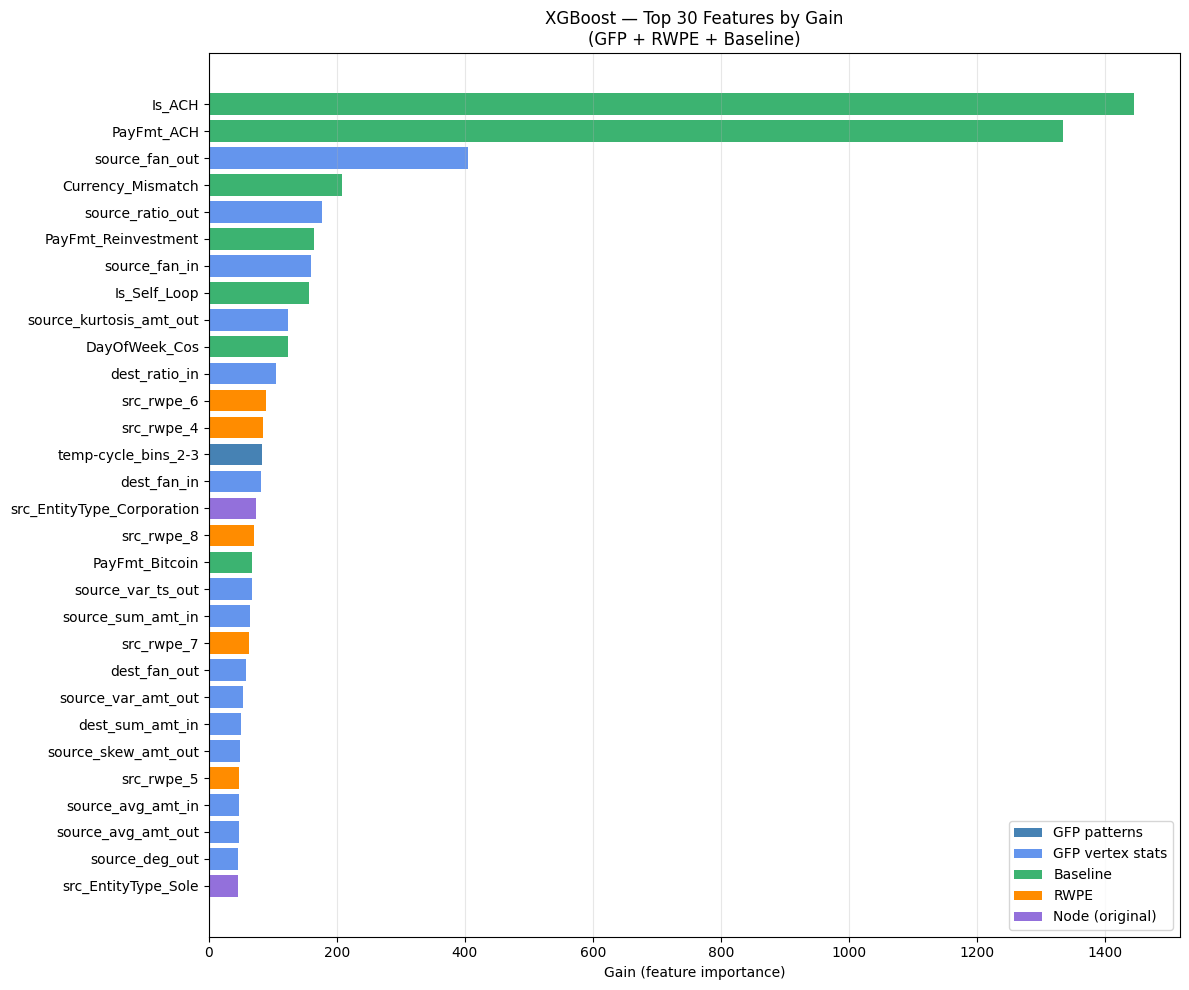

Top 10 features by gain:
                                gain             group
Is_ACH                   1445.456543          Baseline
PayFmt_ACH               1334.631958          Baseline
source_fan_out            405.495911  GFP vertex stats
Currency_Mismatch         207.304489          Baseline
source_ratio_out          177.095947  GFP vertex stats
PayFmt_Reinvestment       163.570511          Baseline
source_fan_in             159.392075  GFP vertex stats
Is_Self_Loop              155.684586          Baseline
source_kurtosis_amt_out   124.089561  GFP vertex stats
DayOfWeek_Cos             123.649437          Baseline


In [41]:
importance   = model.get_score(importance_type='gain')
imp_df = (
    pd.DataFrame.from_dict(importance, orient='index', columns=['gain'])
    .sort_values('gain', ascending=False)
    .head(30)
)

# GFP pattern col names (safe version with brackets replaced)
_safe = lambda c: c.replace('[', '(').replace(']', ')').replace('<', 'lt')
_safe_gfp_pat  = [_safe(c) for c in GFP_FEAT_COLS
                  if any(p in c for p in ['scatter-gather', 'temp-cycle', 'lc-cycle'])]
_safe_gfp_vert = [_safe(c) for c in GFP_FEAT_COLS
                  if any(p in c for p in ['source_', 'dest_'])]
_safe_base     = [_safe(c) for c in BASE_EDGE_COLS]

def feat_group(name):
    """Classify a feature name into its group for colour-coding."""
    if name.startswith('src_rwpe_') or name.startswith('dst_rwpe_'):
        return 'RWPE'
    if name.startswith('src_') or name.startswith('dst_'):
        return 'Node (original)'
    if name in _safe_gfp_pat:
        return 'GFP patterns'
    if name in _safe_gfp_vert:
        return 'GFP vertex stats'
    return 'Baseline'

imp_df['group'] = imp_df.index.map(feat_group)

colors = {
    'GFP patterns'   : 'steelblue',
    'GFP vertex stats': 'cornflowerblue',
    'Baseline'       : 'mediumseagreen',
    'RWPE'           : 'darkorange',
    'Node (original)': 'mediumpurple',
}
bar_colors = imp_df['group'].map(colors)

fig, ax = plt.subplots(figsize=(12, 10))
ax.barh(imp_df.index[::-1], imp_df['gain'][::-1], color=bar_colors.values[::-1])
ax.set_xlabel('Gain (feature importance)')
ax.set_title('XGBoost — Top 30 Features by Gain\n(GFP + RWPE + Baseline)')
legend_elements = [Patch(facecolor=c, label=g) for g, c in colors.items()]
ax.legend(handles=legend_elements, loc='lower right')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('Models/XGBoost_GFP_RWPE/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features by gain:')
print(imp_df[['gain', 'group']].head(10).to_string())

---
## 14. Save predictions & model

In [42]:
today = datetime.now().strftime('%d_%m_%y')

for probs, y, name in [
    (train_probs, y_train, 'train'),
    (val_probs,   y_val,   'val'),
    (test_probs,  y_test,  'test'),
]:
    path = f'{SAVE_DIR}/predictions_{name}_{today}.csv'
    pd.DataFrame({'score': probs, 'label': y}).to_csv(path, index=False)
    print(f'Saved predictions → {path}')

# combine predictions for all set and save as one file for potential future analysis
all_preds = pd.concat([
    pd.DataFrame({'score': train_probs, 'label': y_train, 'split': 'train'}),
    pd.DataFrame({'score': val_probs,   'label': y_val,   'split': 'val'}),
    pd.DataFrame({'score': test_probs,  'label': y_test,  'split': 'test'}),
], ignore_index=True)
all_preds_path = f'{SAVE_DIR}/predictions_all_{today}.csv'
all_preds.to_csv(all_preds_path, index=False)
print(f'Saved combined predictions → {all_preds_path}')

model_path = f'Models/XGBoost_GFP_RWPE/xgb_gfp_rwpe_{today}.json'
model.save_model(model_path)
print(f'\nModel saved → {model_path}')

Saved predictions → Models/XGBoost_GFP_RWPE/Predictions/predictions_train_25_05_26.csv
Saved predictions → Models/XGBoost_GFP_RWPE/Predictions/predictions_val_25_05_26.csv
Saved predictions → Models/XGBoost_GFP_RWPE/Predictions/predictions_test_25_05_26.csv
Saved combined predictions → Models/XGBoost_GFP_RWPE/Predictions/predictions_all_25_05_26.csv

Model saved → Models/XGBoost_GFP_RWPE/xgb_gfp_rwpe_25_05_26.json


---
## 15. Comparison table vs GNN baselines

In [43]:
# Fill in GNN test results from your analysis notebooks
comparison = pd.DataFrame([
    {'Model': 'GINe (baseline features)',        'F1 @0.5': None, 'PR-AUC': None, 'ROC-AUC': None},
    {'Model': 'GINe (GFP features)',             'F1 @0.5': None, 'PR-AUC': None, 'ROC-AUC': None},
    {'Model': 'PNA  (GFP features)',             'F1 @0.5': None, 'PR-AUC': None, 'ROC-AUC': None},
    {'Model': 'XGBoost (GFP + RWPE + Baseline)',
     'F1 @0.5': round(test_metrics['f1_05'],  4),
     'PR-AUC' : round(test_metrics['pr_auc'], 4),
     'ROC-AUC': round(test_metrics['roc_auc'],4)},
]).set_index('Model')

print('=== Test-set comparison — LI-Small ===')
print(comparison.to_string())
comparison.to_csv('Models/XGBoost_GFP_RWPE/comparison_table.csv')
print('\nFill in None values with your GNN results from analysis notebooks.')

=== Test-set comparison — LI-Small ===
                                 F1 @0.5  PR-AUC  ROC-AUC
Model                                                    
GINe (baseline features)             NaN     NaN      NaN
GINe (GFP features)                  NaN     NaN      NaN
PNA  (GFP features)                  NaN     NaN      NaN
XGBoost (GFP + RWPE + Baseline)   0.0767   0.119   0.9755

Fill in None values with your GNN results from analysis notebooks.
